# Symmetric trend filter - does cutting shorts in uptrends help?
The biggest drawdowns were **short squeezes**: the strategy was short while BTC rallied (avg +35%).
The current trend filter only protects the LONG side (flatten longs in downtrends). This tests a
**symmetric** version that also flattens NET-SHORT exposure in an UPTREND (price > MA).

Compares asymmetric (current) vs symmetric on **BTC and ETH** - return, max drawdown, Sharpe,
Calmar - plus the biggest-drawdown table for each. A good fix lowers drawdown on BOTH coins
without killing return. (`TREND_SYMMETRIC` in protected_strategy.py is OFF by default; this
notebook tests it via the `symmetric=` argument - nothing in the live strategy changes yet.)

## 1. Setup

In [1]:
import os, sys
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
os.chdir(r"C:\Users\sliso\BTC_Live")
for m in ['strategy_patterns','strategy_funnel','test_single_strategy','indicators_loader','protected_strategy']:
    sys.modules.pop(m, None)
import strategy_funnel as sf
import protected_strategy as ps
PPY = 8760.0
print("trend MA", ps.MA_WIN, "| symmetric default:", ps.TREND_SYMMETRIC)

trend MA 300 | symmetric default: False


## 2. Helpers - stats + drawdown episodes

In [2]:
def equity(pnl): return np.cumprod(1.0 + pnl)
def maxdd(eq): pk=np.maximum.accumulate(eq); return float(np.max((pk-eq)/np.where(pk>0,pk,1)))
def stats(pnl, years):
    eq=equity(pnl)
    return {'total_return':round(eq[-1]-1,3),'max_drawdown':round(maxdd(eq),3),
            'sharpe':round(sf.sharpe(pnl,PPY),2),
            'calmar':round((pnl.mean()*PPY)/maxdd(eq),2) if maxdd(eq)>0 else np.inf}

def episodes(pnl, dates, close, net, top=6):
    eq=equity(pnl); pk=eq[0];pk_i=0;tr=eq[0];tr_i=0;ind=False;eps=[]
    for i in range(1,len(eq)):
        if eq[i]>=pk:
            if ind: eps.append((pk_i,tr_i,(pk-tr)/pk)); ind=False
            pk=eq[i];pk_i=i;tr=eq[i];tr_i=i
        else:
            ind=True
            if eq[i]<tr: tr=eq[i];tr_i=i
    if ind: eps.append((pk_i,tr_i,(pk-tr)/pk))
    eps.sort(key=lambda e:-e[2])
    rows=[]
    for pk_i,tr_i,d in eps[:top]:
        sl=slice(pk_i,tr_i+1)
        rows.append({'start':str(dates[pk_i].date()),'depth':f"{d*100:.1f}%",
                     'BTC_move':f"{(close[tr_i]/close[pk_i]-1)*100:+.0f}%",
                     'pct_short':f"{(net[sl]<0).mean()*100:.0f}%"})
    return pd.DataFrame(rows)

## 3. Compute both variants on BTC

In [3]:
def load_variant(csv, start, symmetric):
    df = sf.load_ohlc(csv)
    pnl, net, dates = ps.protected_pnl_series(df, start, None, symmetric=symmetric)
    close = df['Close'].reindex(dates).values.astype(float)
    return pnl, net, dates, close

BTC_START = "2019-01-01"
pa, neta, da, ca = load_variant("BTCUSDT_1h.csv", BTC_START, symmetric=False)  # asymmetric (current)
psym, ns, ds, cs = load_variant("BTCUSDT_1h.csv", BTC_START, symmetric=True)   # symmetric (new)
yrs = len(pa)/PPY
print("BTC:")
display(pd.DataFrame({'asymmetric (current)':stats(pa,yrs),'symmetric (new)':stats(psym,yrs)}).T)

BTC:


,total_return,max_drawdown,sharpe,calmar
asymmetric (current),6.338,0.065,3.42,4.15
symmetric (new),10.309,0.028,4.45,11.63


## 4. Did the short-squeeze drawdowns shrink? (BTC)

In [4]:
print("ASYMMETRIC - biggest drawdowns:"); display(episodes(pa, da, ca, neta))
print("SYMMETRIC  - biggest drawdowns:"); display(episodes(psym, ds, cs, ns))

ASYMMETRIC - biggest drawdowns:


,start,depth,BTC_move,pct_short
0,2023-01-03,6.5%,+26%,60%
1,2019-05-02,6.5%,+156%,19%
2,2020-10-09,5.5%,+20%,77%
3,2019-02-08,4.2%,+8%,22%
4,2023-09-19,3.9%,+5%,10%
5,2024-07-05,3.5%,+29%,68%


SYMMETRIC  - biggest drawdowns:


,start,depth,BTC_move,pct_short
0,2019-04-03,2.8%,-6%,0%
1,2019-10-26,2.7%,-10%,0%
2,2022-03-02,2.5%,-11%,0%
3,2024-01-11,2.2%,-6%,0%
4,2023-08-29,2.1%,-4%,0%
5,2023-09-19,2.1%,-4%,0%


## 5. Equity curves (BTC)

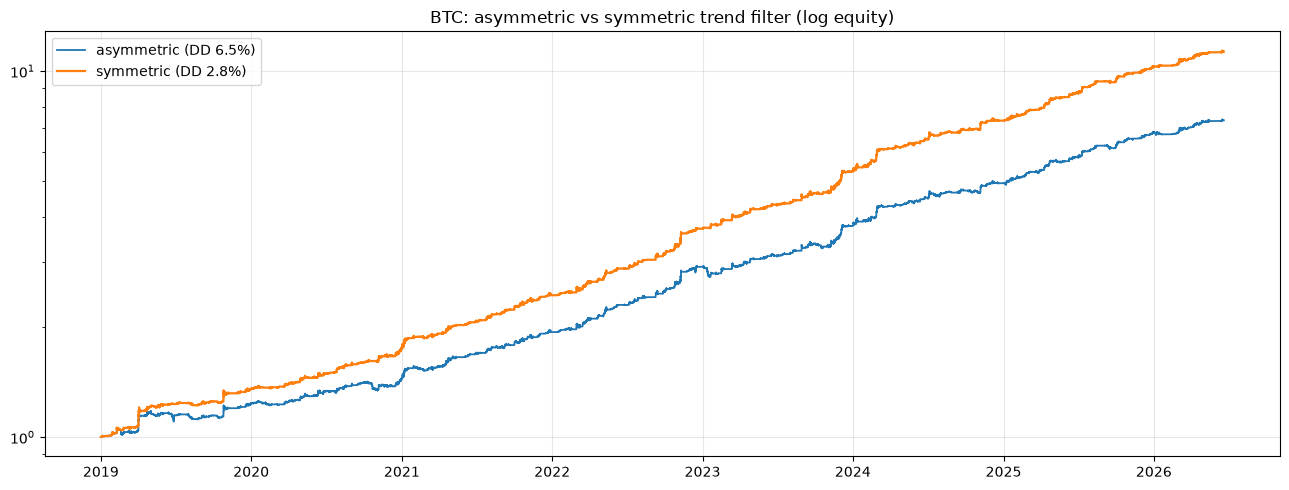

In [5]:
plt.figure(figsize=(13,5))
plt.plot(da, equity(pa), lw=1.3, label=f"asymmetric (DD {maxdd(equity(pa)):.1%})")
plt.plot(ds, equity(psym), lw=1.6, label=f"symmetric (DD {maxdd(equity(psym)):.1%})")
plt.legend(); plt.grid(alpha=.3); plt.yscale('log')
plt.title("BTC: asymmetric vs symmetric trend filter (log equity)"); plt.tight_layout()

## 6. Confirm on ETH (must help on BOTH or it's fitted)

In [6]:
ea, en, ed, ec = load_variant("ETHUSDT_1h.csv", "2019-01-01", symmetric=False)
es, esn, esd, esc = load_variant("ETHUSDT_1h.csv", "2019-01-01", symmetric=True)
eyrs = len(ea)/PPY
print("ETH:")
display(pd.DataFrame({'asymmetric (current)':stats(ea,eyrs),'symmetric (new)':stats(es,eyrs)}).T)

ETH:


,total_return,max_drawdown,sharpe,calmar
asymmetric (current),6.077,0.109,3.46,2.43
symmetric (new),9.186,0.042,4.32,7.38


## 7. Verdict

Adopt the symmetric filter only if, on **both** BTC and ETH, it **lowers max drawdown** (and ideally
raises Calmar) **without** materially cutting return. If it helps BTC but hurts ETH, it is fitted to
BTC's squeezes - don't adopt it.

To make it the live default once satisfied: set `TREND_SYMMETRIC = True` in `protected_strategy.py`.